In [2]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

### Sample 1

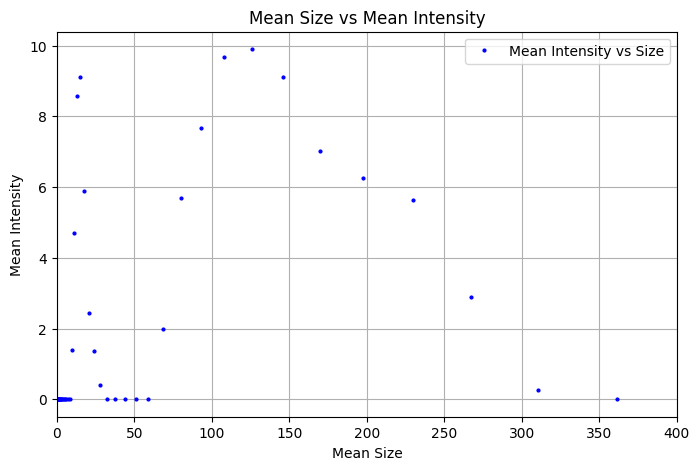

In [13]:
import pandas as pd

# Import Excel data
file_path = "sample 1 all datas.xlsx"
df = pd.read_excel(file_path, sheet_name="Feuil1")

# SIZE INTENSITY PLOT==========================================================================
#extract test values
size_1 = df.iloc[:, 0]  # Test 1 sizes
intensity_1 = df.iloc[:, 1]  

size_2 = df.iloc[:, 3]  # Test 2 sizes
intensity_2 = df.iloc[:, 4]  

size_3 = df.iloc[:, 6]  # Test 3 sizes
intensity_3 = df.iloc[:, 7]  

# compute mean values of the three test
mean_size = pd.concat([size_1, size_2, size_3], axis=1).mean(axis=1)
mean_intensity = pd.concat([intensity_1, intensity_2, intensity_3], axis=1).mean(axis=1)

#fitting
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Initial guesses for the fit parameters
A_guess = max(mean_intensity)  # Hauteur du pic
mu_guess = mean_size[np.argmax(mean_intensity)]  # Position du pic
sigma_guess = (max(mean_size) - min(mean_size)) / 6  # Largeur estimée

popt, _ = curve_fit(gaussian, mean_size, mean_intensity, p0=[A_guess, mu_guess, sigma_guess])

# Extract fitted parameters
A_fit, mu_fit, sigma_fit = popt
#plot mean values
plt.figure(figsize=(8, 5))
plt.plot(mean_size, mean_intensity, marker='o', markersize=2, linestyle=' ', color='b', label="Mean Intensity vs Size")

plt.xlabel("Mean Size")
plt.xlim([0,400])
plt.ylabel("Mean Intensity")
plt.title("Mean Size vs Mean Intensity")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Fonction pour tracer le graphe spécifique
